In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATASET_PATH = Path("../data/raw/MachineLearningCVE")

csv_files = sorted(DATASET_PATH.glob("*.csv"))

dfs = []

for file in csv_files:
    print(f"Loading {file.name}...")
    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()  # Strip whitespace from column names

    dfs.append(df)

print(f"\nLoaded {len(dfs)} datasets.")


Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Wednesday-workingHours.pcap_ISCX.csv...

Loaded 8 datasets.


In [3]:
df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")


Combined dataset shape: (2830743, 79)


In [4]:
# verifying the combined dataset
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

In [6]:
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [7]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 308381


In [8]:
df = df.drop_duplicates()
print(f"\nShape after removing duplicates: {df.shape}")


Shape after removing duplicates: (2522362, 79)


In [9]:
df.duplicated().sum()  # Verify that duplicates have been removed

np.int64(0)

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
np.isinf(numeric_df).sum().sum()  # Check for infinite values in numeric columns

np.int64(2775)

In [11]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinite values with NaN

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [12]:
numeric_df = df.select_dtypes(include=[np.number])
np.isinf(numeric_df).sum().sum()  # Check the dataset to ensure no infinite values remain

np.int64(0)

In [13]:
df.isnull().sum().sort_values(ascending=False).head(20)  # Check for missing values in the dataset

Flow Bytes/s                   1564
Flow Packets/s                 1564
Flow Duration                     0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Destination Port                  0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Std             0
Fwd Packet Length Mean            0
Bwd Packet Length Max             0
Bwd Packet Length Min             0
Bwd Packet Length Mean            0
Total Fwd Packets                 0
Bwd Packet Length Std             0
Flow IAT Mean                     0
Flow IAT Std                      0
Flow IAT Max                      0
Flow IAT Min                      0
dtype: int64

In [16]:
df = df.dropna()  # Remove rows with missing values and update the DataFrame

In [17]:
df.isnull().sum().sort_values(ascending=False).head(20)  # Verify that missing values have been removed

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
dtype: int64

In [18]:
df["Label"].value_counts()

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [19]:
(df["Label"].value_counts(normalize=True) * 100).round(2)  # Display class distribution in percentage

Label
BENIGN                        83.11
DoS Hulk                       6.86
DDoS                           5.08
PortScan                       3.60
DoS GoldenEye                  0.41
FTP-Patator                    0.24
DoS slowloris                  0.21
DoS Slowhttptest               0.21
SSH-Patator                    0.13
Bot                            0.08
Web Attack � Brute Force       0.06
Web Attack � XSS               0.03
Infiltration                   0.00
Web Attack � Sql Injection     0.00
Heartbleed                     0.00
Name: proportion, dtype: float64

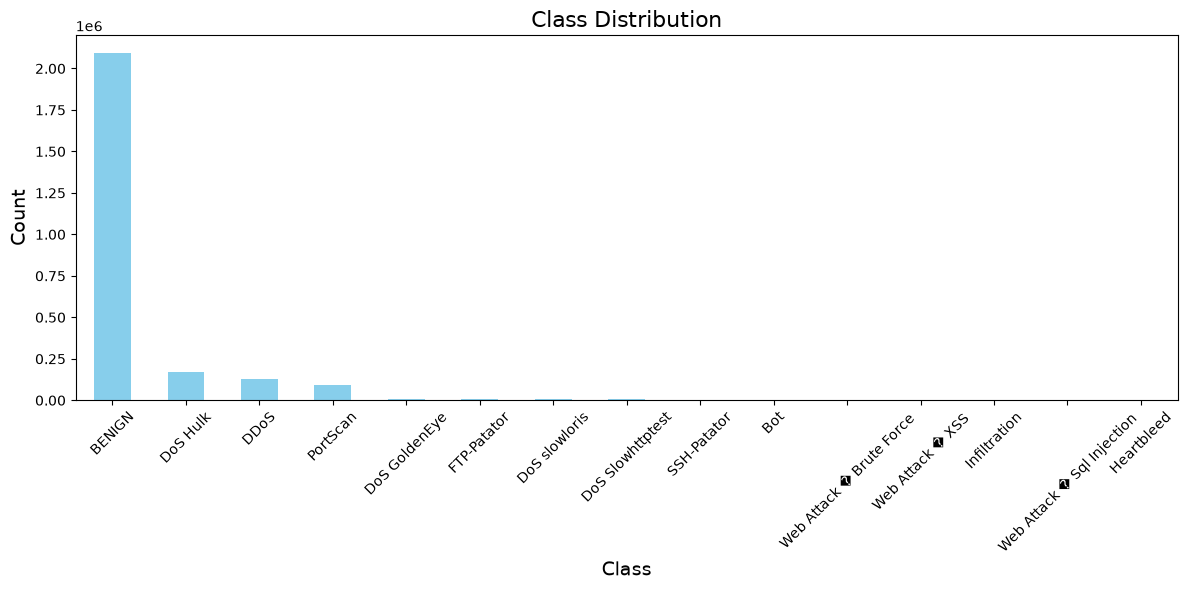

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df["Label"].value_counts().plot(kind="bar", color="skyblue")

plt.title("Class Distribution", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Label_encoded"] = label_encoder.fit_transform(df["Label"])

In [22]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

mapping

{'BENIGN': np.int64(0),
 'Bot': np.int64(1),
 'DDoS': np.int64(2),
 'DoS GoldenEye': np.int64(3),
 'DoS Hulk': np.int64(4),
 'DoS Slowhttptest': np.int64(5),
 'DoS slowloris': np.int64(6),
 'FTP-Patator': np.int64(7),
 'Heartbleed': np.int64(8),
 'Infiltration': np.int64(9),
 'PortScan': np.int64(10),
 'SSH-Patator': np.int64(11),
 'Web Attack � Brute Force': np.int64(12),
 'Web Attack � Sql Injection': np.int64(13),
 'Web Attack � XSS': np.int64(14)}

In [25]:
X = df.drop(columns=["Label", "Label_encoded"]) # Separating features and target variable
y = df["Label_encoded"]  # Target variable

In [26]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2520798, 78)
Target shape: (2520798,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
df.to_csv("../data/processed/cicids2017_clean.csv", index=False) # save the cleaned dataset to a new CSV file

In [29]:
import joblib

joblib.dump(X_train, "../data/processed/X_train.pkl")
joblib.dump(X_test, "../data/processed/X_test.pkl")

joblib.dump(y_train, "../data/processed/y_train.pkl")
joblib.dump(y_test, "../data/processed/y_test.pkl")

['../data/processed/y_test.pkl']

In [30]:
joblib.dump(label_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']